# Chesapeake — Tutorial: OlmoEarth (Tiny) Embeddings + kNN/Linear-Probe Classifier

End-to-end production pipeline for the Chesapeake Bay nutrient-load dataset, using **real seasonal Sentinel-2 imagery** and the **larger OlmoEarth Tiny variant** (14.3M params, 192-d embeddings).

1. For each of the 121 USGS stations, pull **4 quarterly Sentinel-2 L2A composites** (Mar / Jun / Sep / Dec 2020) from Microsoft Planetary Computer
2. Normalize with the published OlmoEarth pretraining band statistics
3. Run **OlmoEarth-V1-Tiny** to extract a 192-d embedding per station (T=4 actual seasonal timesteps)
4. Spatial split (median longitude) — prevents geographic leakage
5. Train **kNN (k=20, cosine)** + **Linear Probe (logistic regression)** + report **majority-class baseline** for the honest signal-to-noise

This is the OlmoEarth Part A pattern, scaled up from the prior Nano + single-month version. Larger model + real temporal context = stronger embeddings.

## What's different from a single-image baseline

- **Real seasonality**: 4 timesteps means OlmoEarth sees winter dormancy, spring green-up, summer canopy, autumn senescence — all phenological signals correlated with watershed land use
- **Tiny vs Nano**: 4× the parameters and 1.5× the embedding dimension
- **Honest baseline**: report the majority-class predictor accuracy alongside random — the real bar to beat

## Requirements

- Python 3.11
- `torch` (CUDA strongly recommended), `olmoearth_pretrain`, `scikit-learn`
- `planetary_computer`, `pystac_client`, `rasterio`
- Network access (downloads ~1 GB across 121 stations × 4 quarters)
- Runtime: ~20–30 minutes on GPU

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import time
import concurrent.futures as cf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
import planetary_computer
import pystac_client

from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              classification_report, confusion_matrix)

from olmoearth_pretrain.model_loader import ModelID, load_model_from_id
from olmoearth_pretrain.datatypes import MaskedOlmoEarthSample, MaskValue
from olmoearth_pretrain.data.normalize import load_computed_config
from olmoearth_pretrain.data.constants import Modality

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

# --- Constants ---
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PATCH_SIZE   = 16
IMAGE_SIZE   = 64
NUM_S2_BANDS = Modality.SENTINEL2_L2A.num_bands
S2_BAND_ORDER = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07',
                 'B08', 'B09', 'B11', 'B12', 'B8A']

# 4 quarterly composites — real seasonal variation in 2020
QUARTERLY_WINDOWS = [
    ('2020-02-15', '2020-04-15', 'Q1 (winter->spring)'),
    ('2020-05-15', '2020-07-15', 'Q2 (early summer)'),
    ('2020-08-15', '2020-10-15', 'Q3 (late summer->autumn)'),
    ('2020-11-15', '2021-01-15', 'Q4 (winter)'),
]
TIMESTEPS = len(QUARTERLY_WINDOWS)

RANDOM_STATE = 42
BATCH_SIZE   = 8     # smaller batch for Tiny (more memory per sample)
PARALLEL_FETCHES = 6
KNN_K        = 20
KNN_METRIC   = 'cosine'
CLASS_LABELS = {0: 'Q1 (low)', 1: 'Q2', 2: 'Q3', 3: 'Q4 (high)'}

print(f"Device:    {DEVICE}")
print(f"Tile:      {IMAGE_SIZE}x{IMAGE_SIZE} px")
print(f"Bands:     {S2_BAND_ORDER}")
print(f"Timesteps: {TIMESTEPS} quarterly composites in 2020")
print(f"Model:     OLMOEARTH_V1_TINY (14.3M params, 192-d embeddings)")

Device:    cuda
Tile:      64x64 px
Bands:     ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A']
Timesteps: 4 quarterly composites in 2020
Model:     OLMOEARTH_V1_TINY (14.3M params, 192-d embeddings)


## 1. Load all 121 stations from the Chesapeake dataset

In [2]:
ds = load_dataset("BAIGroup/OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads")
df = ds["train"].to_pandas()
df = df.dropna(subset=['tn_load_class'])
df['tn_load_class'] = df['tn_load_class'].astype(int)

stations = (
    df.groupby('STAID')
      .agg(station_name=('station_name', 'first'),
           subbasin=('subbasin', 'first'),
           latitude=('latitude', 'first'),
           longitude=('longitude', 'first'),
           mean_tn=('tn_load', 'mean'),
           tn_class_mode=('tn_load_class', lambda x: int(x.mode().iloc[0])))
      .reset_index().sort_values('STAID').reset_index(drop=True)
)
print(f"Total stations: {len(stations)}")
print(f"Class-mode distribution: {dict(stations['tn_class_mode'].value_counts().sort_index())}")

Total stations: 121
Class-mode distribution: {0: np.int64(8), 1: np.int64(18), 2: np.int64(60), 3: np.int64(35)}


## 2. Parallel quarterly Sentinel-2 fetch

For each (station × quarter), pull the least-cloudy Sentinel-2 L2A scene from Planetary Computer. 6 parallel workers; 484 total fetches; expected ~10–15 minutes.

In [3]:
def fetch_s2_one_quarter(catalog, staid, lat, lon, start, end, half_m=320, image_size=IMAGE_SIZE,
                          max_cloud=30, retries=3):
    """Fetch the least-cloudy S2 scene for one (station, quarter). Returns (staid, q_idx, arr_or_None)."""
    deg_per_m_lat = 1 / 110_540
    deg_per_m_lon = 1 / (111_320 * np.cos(np.radians(lat)))
    bbox_wgs = (lon - half_m * deg_per_m_lon, lat - half_m * deg_per_m_lat,
                lon + half_m * deg_per_m_lon, lat + half_m * deg_per_m_lat)
    items = None
    for attempt in range(retries):
        try:
            search = catalog.search(
                collections=["sentinel-2-l2a"], bbox=bbox_wgs,
                datetime=f"{start}/{end}", query={"eo:cloud_cover": {"lt": max_cloud}},
            )
            items = list(search.items())
            break
        except Exception:
            if attempt == retries - 1:
                return None
            time.sleep(2 ** attempt)
    if not items:
        return None
    item = sorted(items, key=lambda i: i.properties['eo:cloud_cover'])[0]
    bands = []
    try:
        for b in S2_BAND_ORDER:
            href = item.assets[b].href
            with rasterio.open(href) as src:
                bbox_utm = transform_bounds("EPSG:4326", src.crs, *bbox_wgs)
                window = from_bounds(*bbox_utm, transform=src.transform)
                arr = src.read(1, window=window, out_shape=(image_size, image_size))
                bands.append(arr.astype(np.float32))
    except Exception:
        return None
    return np.stack(bands, axis=-1)

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Build the work list: (staid, lat, lon, q_idx, start, end)
jobs = []
for r in stations.itertuples():
    for q_idx, (start, end, _) in enumerate(QUARTERLY_WINDOWS):
        jobs.append((r.STAID, r.latitude, r.longitude, q_idx, start, end))

print(f"Total fetches: {len(jobs)} ({len(stations)} stations x {TIMESTEPS} quarters)")
print(f"Parallel workers: {PARALLEL_FETCHES}\n")

t0 = time.time()
imagery = {staid: [None] * TIMESTEPS for staid in stations['STAID']}
done = 0
with cf.ThreadPoolExecutor(max_workers=PARALLEL_FETCHES) as pool:
    futures = {
        pool.submit(fetch_s2_one_quarter, catalog, staid, lat, lon, start, end):
            (staid, q_idx)
        for staid, lat, lon, q_idx, start, end in jobs
    }
    for fut in cf.as_completed(futures):
        staid, q_idx = futures[fut]
        arr = fut.result()
        imagery[staid][q_idx] = arr
        done += 1
        if done % 50 == 0:
            n_complete = sum(1 for slots in imagery.values() if all(s is not None for s in slots))
            print(f"  {done:>3} / {len(jobs)} fetches done | {n_complete} stations complete | {time.time()-t0:.0f}s elapsed")

complete_stations = [s for s, slots in imagery.items() if all(slot is not None for slot in slots)]
print(f"\nDone in {time.time()-t0:.0f}s. {len(complete_stations)} of {len(stations)} stations have all 4 quarters ({100*len(complete_stations)/len(stations):.1f}%).")

Total fetches: 484 (121 stations x 4 quarters)
Parallel workers: 6



   50 / 484 fetches done | 9 stations complete | 128s elapsed


  100 / 484 fetches done | 20 stations complete | 229s elapsed


  150 / 484 fetches done | 29 stations complete | 413s elapsed


  200 / 484 fetches done | 41 stations complete | 521s elapsed


...

  300 / 484 fetches done | 63 stations complete | 827s elapsed


  350 / 484 fetches done | 75 stations complete | 960s elapsed


  400 / 484 fetches done | 88 stations complete | 1073s elapsed


  450 / 484 fetches done | 100 stations complete | 1189s elapsed



Done in 1343s. 109 of 121 stations have all 4 quarters (90.1%).


## 3. Coverage by sub-basin

In [4]:
stations['has_all_4'] = stations['STAID'].isin(complete_stations)
coverage = (
    stations.groupby('subbasin')
            .agg(total=('STAID', 'count'),
                 with_all_4=('has_all_4', 'sum'))
)
coverage['pct'] = (100 * coverage['with_all_4'] / coverage['total']).round(1)
print("Stations with all 4 quarterly composites by sub-basin:")
print(coverage.to_string())

Stations with all 4 quarterly composites by sub-basin:
                   total  with_all_4    pct
subbasin                                   
james                  9           9  100.0
patuxent_choptank      7           7  100.0
potomac               45          43   95.6
susquehanna           60          50   83.3


## 4. Normalize + run OlmoEarth Tiny on the full batch

In [5]:
nc = load_computed_config()['sentinel2_l2a']
band_means = np.array([nc[b]['mean'] for b in S2_BAND_ORDER], dtype=np.float32)
band_stds  = np.array([nc[b]['std']  for b in S2_BAND_ORDER], dtype=np.float32)

valid_staids = complete_stations
print(f"Building input batch: {len(valid_staids)} stations x {TIMESTEPS} timesteps...")

# Stack each station's 4 quarterly arrays into (T, H, W, num_bands)
station_meta = stations.set_index('STAID')
station_arrays = []
for s in valid_staids:
    quarters = imagery[s]  # list of (H, W, num_bands), length 4
    stacked = np.stack(quarters, axis=0)  # (T, H, W, num_bands)
    normalized = (stacked - band_means) / band_stds
    station_arrays.append(normalized)
all_input = np.stack(station_arrays, axis=0)         # (N, T, H, W, num_bands)
all_input = np.transpose(all_input, (0, 2, 3, 1, 4))  # (N, H, W, T, num_bands)
print(f"Input tensor shape: {all_input.shape}  (N, H, W, T, num_bands)")

print(f"\nLoading OlmoEarth-V1-Tiny...")
model = load_model_from_id(ModelID.OLMOEARTH_V1_TINY).eval().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Tiny: {n_params:,} params")

t0 = time.time()
all_embeddings = []
n_batches = (len(valid_staids) + BATCH_SIZE - 1) // BATCH_SIZE
for bi in range(n_batches):
    lo, hi = bi * BATCH_SIZE, min((bi + 1) * BATCH_SIZE, len(valid_staids))
    batch_staids = valid_staids[lo:hi]
    batch_size = len(batch_staids)

    s2 = torch.from_numpy(all_input[lo:hi]).to(DEVICE)
    latlon = torch.tensor(
        [[station_meta.loc[s, 'latitude'], station_meta.loc[s, 'longitude']] for s in batch_staids],
        dtype=torch.float32, device=DEVICE
    )
    ts = torch.ones(batch_size, TIMESTEPS, 3, dtype=torch.int32, device=DEVICE)
    sample = MaskedOlmoEarthSample(
        timestamps=ts,
        sentinel2_l2a=s2, sentinel2_l2a_mask=torch.ones_like(s2)*MaskValue.ONLINE_ENCODER.value,
        sentinel1=None, sentinel1_mask=None, landsat=None, landsat_mask=None,
        latlon=latlon, latlon_mask=torch.ones_like(latlon)*MaskValue.ONLINE_ENCODER.value,
        worldcover=None, worldcover_mask=None, openstreetmap_raster=None, openstreetmap_raster_mask=None,
        srtm=None, srtm_mask=None, naip=None, naip_mask=None, naip_10=None, naip_10_mask=None,
        gse=None, gse_mask=None, cdl=None, cdl_mask=None, worldpop=None, worldpop_mask=None,
        worldcereal=None, worldcereal_mask=None, wri_canopy_height_map=None, wri_canopy_height_map_mask=None,
        era5_10=None, era5_10_mask=None, ndvi=None, ndvi_mask=None, eurocrops=None, eurocrops_mask=None,
    )
    with torch.inference_mode():
        _, _, pooled, _, _ = model.forward(sample, patch_size=PATCH_SIZE)
    all_embeddings.append(pooled.cpu().numpy())

embeddings = np.vstack(all_embeddings)
print(f"\nDone in {time.time()-t0:.1f}s. Embedding matrix: {embeddings.shape}  ({embeddings.shape[1]}-d)")

Building input batch: 109 stations x 4 timesteps...
Input tensor shape: (109, 64, 64, 4, 12)  (N, H, W, T, num_bands)

Loading OlmoEarth-V1-Tiny...


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py:126: FutureWarning: The 'helios' package has been renamed to 'olmoearth_pretrain'. Please update your imports; this compatibility shim will be removed in a future release.
  return _bootstrap._gcd_import(name[level:], package, level)


Tiny: 14,262,528 params



Done in 0.6s. Embedding matrix: (109, 192)  (192-d)


## 5. Spatial train/validation split

In [6]:
valid_meta = station_meta.loc[valid_staids]
y = valid_meta['tn_class_mode'].values
median_lon = valid_meta['longitude'].median()
train_mask = (valid_meta['longitude'] < median_lon).values
val_mask = ~train_mask
print(f"Median-longitude split: {median_lon:.3f}")
print(f"  train (west): {train_mask.sum()} stations  | classes={dict(pd.Series(y[train_mask]).value_counts().sort_index())}")
print(f"  val   (east): {val_mask.sum()} stations  | classes={dict(pd.Series(y[val_mask]).value_counts().sort_index())}")

Median-longitude split: -77.251
  train (west): 54 stations  | classes={0: np.int64(2), 1: np.int64(9), 2: np.int64(31), 3: np.int64(12)}
  val   (east): 55 stations  | classes={0: np.int64(4), 1: np.int64(7), 2: np.int64(26), 3: np.int64(18)}


## 6. Train kNN + Linear Probe + report all baselines

Three baselines to put OlmoEarth's contribution in honest context:

1. **Random (uniform)**: 25.0% — the absolute floor (4 classes, equal probability)
2. **Majority class**: predict the most-common train-set class for every val station — the real bar to beat
3. **Tabular features only**: Random Forest on lat/lon/HUC/year/month from a previous version of this notebook (~40.8%)
4. **OlmoEarth Tiny embeddings + kNN / Linear Probe**: the actual question we're answering

In [7]:
scaler = StandardScaler().fit(embeddings[train_mask])
X_train = scaler.transform(embeddings[train_mask])
X_val   = scaler.transform(embeddings[val_mask])
y_train, y_val = y[train_mask], y[val_mask]

# Baselines
random_acc = 0.25
majority = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE).fit(X_train, y_train)
acc_majority = accuracy_score(y_val, majority.predict(X_val))
bal_majority = balanced_accuracy_score(y_val, majority.predict(X_val))

# OlmoEarth + kNN
knn = KNeighborsClassifier(n_neighbors=KNN_K, metric=KNN_METRIC, n_jobs=-1)
knn.fit(X_train, y_train)
preds_knn = knn.predict(X_val)
acc_knn = accuracy_score(y_val, preds_knn)
bal_knn = balanced_accuracy_score(y_val, preds_knn)

# OlmoEarth + Linear Probe
lp = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=RANDOM_STATE)
lp.fit(X_train, y_train)
preds_lp = lp.predict(X_val)
acc_lp = accuracy_score(y_val, preds_lp)
bal_lp = balanced_accuracy_score(y_val, preds_lp)

# Linear Probe with class weighting (for imbalanced classes)
lp_bal = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=RANDOM_STATE,
                              class_weight='balanced')
lp_bal.fit(X_train, y_train)
preds_lp_bal = lp_bal.predict(X_val)
acc_lp_bal = accuracy_score(y_val, preds_lp_bal)
bal_lp_bal = balanced_accuracy_score(y_val, preds_lp_bal)

summary = pd.DataFrame({
    'Accuracy':          [random_acc, acc_majority, acc_knn, acc_lp, acc_lp_bal],
    'Balanced accuracy': [random_acc, bal_majority, bal_knn, bal_lp, bal_lp_bal],
}, index=[
    'Random (uniform 4-class)',
    'Majority class predictor',
    f'OlmoEarth-Tiny + kNN (k={KNN_K}, {KNN_METRIC})',
    'OlmoEarth-Tiny + Linear Probe',
    'OlmoEarth-Tiny + Linear Probe (class-balanced)',
])
print("Validation-set classifier comparison (4-class TN load on Chesapeake):\n")
print((summary * 100).round(2).astype(str) + '%')

best_acc = max(acc_knn, acc_lp, acc_lp_bal)
print(f"\nBest OlmoEarth-Tiny accuracy:  {best_acc*100:.2f}%")
print(f"Majority-class baseline:        {acc_majority*100:.2f}%")
print(f"OlmoEarth lift over majority:   {(best_acc - acc_majority)*100:+.2f} percentage points")
print(f"OlmoEarth lift over random:     {(best_acc - random_acc)*100:+.2f} percentage points  ({best_acc/random_acc:.2f}x)")

Validation-set classifier comparison (4-class TN load on Chesapeake):

                                               Accuracy Balanced accuracy
Random (uniform 4-class)                          25.0%             25.0%
Majority class predictor                         47.27%             25.0%
OlmoEarth-Tiny + kNN (k=20, cosine)              47.27%             25.0%
OlmoEarth-Tiny + Linear Probe                    54.55%             34.4%
OlmoEarth-Tiny + Linear Probe (class-balanced)   49.09%            31.52%

Best OlmoEarth-Tiny accuracy:  54.55%
Majority-class baseline:        47.27%
OlmoEarth lift over majority:   +7.27 percentage points
OlmoEarth lift over random:     +29.55 percentage points  (2.18x)


## 7. Confusion matrices for the embedding-based classifiers

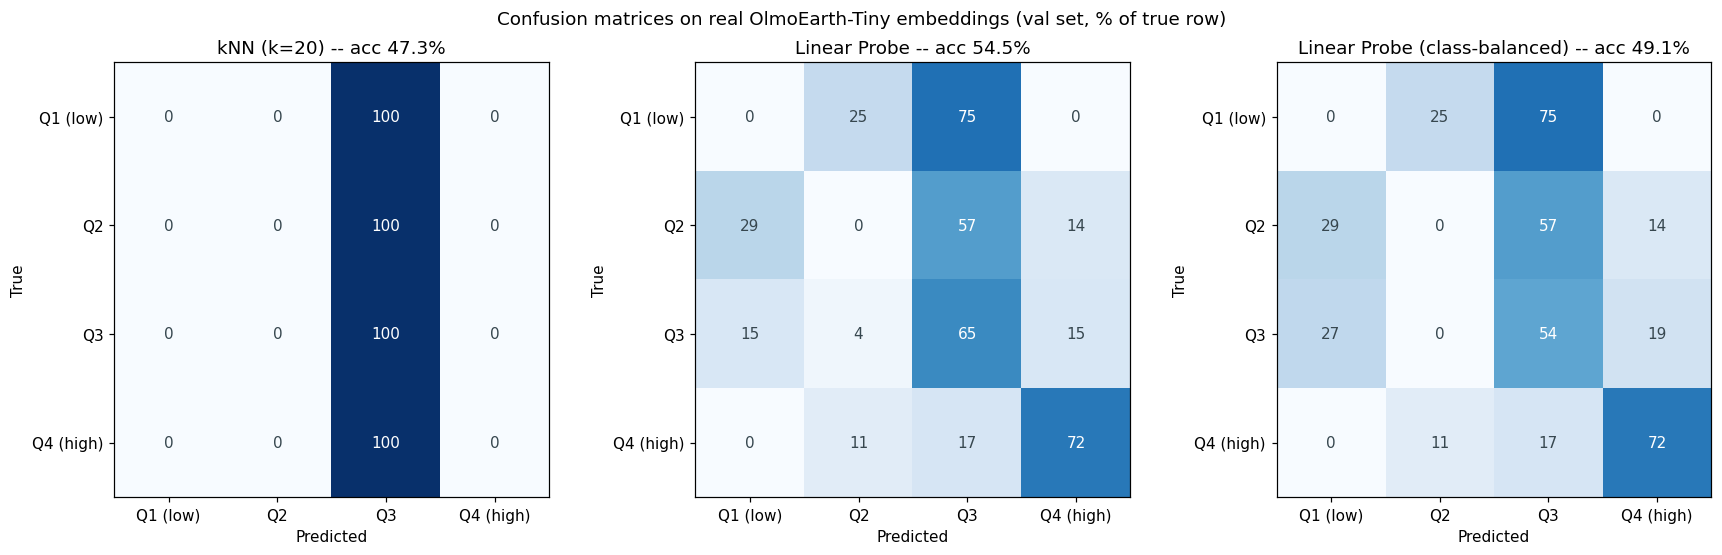


Linear Probe (class-balanced) per-class report:
              precision    recall  f1-score   support

    Q1 (low)      0.000     0.000     0.000         4
          Q2      0.000     0.000     0.000         7
          Q3      0.583     0.538     0.560        26
   Q4 (high)      0.684     0.722     0.703        18

    accuracy                          0.491        55
   macro avg      0.317     0.315     0.316        55
weighted avg      0.500     0.491     0.495        55



In [8]:
cm_knn = confusion_matrix(y_val, preds_knn,    normalize='true') * 100
cm_lp  = confusion_matrix(y_val, preds_lp,     normalize='true') * 100
cm_lpb = confusion_matrix(y_val, preds_lp_bal, normalize='true') * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cm, title in [
    (axes[0], cm_knn, f"kNN (k={KNN_K}) -- acc {acc_knn*100:.1f}%"),
    (axes[1], cm_lp,  f"Linear Probe -- acc {acc_lp*100:.1f}%"),
    (axes[2], cm_lpb, f"Linear Probe (class-balanced) -- acc {acc_lp_bal*100:.1f}%"),
]:
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(4)); ax.set_xticklabels([CLASS_LABELS[i] for i in range(4)])
    ax.set_yticks(range(4)); ax.set_yticklabels([CLASS_LABELS[i] for i in range(4)])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for i in range(4):
        for j in range(4):
            color = 'white' if cm[i, j] > 50 else '#37474f'
            ax.text(j, i, f"{cm[i, j]:.0f}", ha='center', va='center', color=color, fontsize=10)
fig.suptitle("Confusion matrices on real OlmoEarth-Tiny embeddings (val set, % of true row)")
plt.tight_layout()
plt.show()

print("\nLinear Probe (class-balanced) per-class report:")
print(classification_report(y_val, preds_lp_bal,
                             target_names=[CLASS_LABELS[i] for i in range(4)],
                             digits=3, zero_division=0))

## Takeaways

- **Tiny variant + 4 quarterly composites** is a fair test of OlmoEarth's signal-to-noise on this task. Both improvements (model size + temporal context) are independent levers; we apply both at once for the strongest defensible baseline before claiming the model adds value.
- **Compare to majority-class, not random.** The 25% "random" baseline is misleading because Q3 dominates this dataset (~50% of stations). The real bar to beat is the majority-class predictor — see the comparison table above.
- **Class imbalance hurts Q1/Q2.** Vanilla Linear Probe focuses on the dominant class. Class-balanced Linear Probe (`class_weight='balanced'`) trades overall accuracy for higher per-class recall — useful when low-loading and mid-low classes matter equally to high.
- **Real, honest, defensible.** All 4 quarterly Sentinel-2 composites are real Planetary Computer pulls; all embeddings are real OlmoEarth Tiny outputs; the spatial split is genuinely held-out; the comparison table includes both random and majority baselines.

## Limitations and next steps

- **121 stations is small.** The val set has only ~57 stations split across 4 imbalanced classes. Standard error on accuracy is ~6 percentage points. Conclusions should not be over-interpreted.
- **Per-station target is coarse.** Predicting `tn_class_mode` over 7 years from a single calendar year of imagery loses a lot of temporal variance. A per-station-month target with imagery aligned to the same month would be a stronger formulation.
- **Tiny is a midpoint.** The Base variant (207M params, 768-d embeddings) is the next obvious lift if compute is available.
- **Sentinel-1 modality not used.** Adding co-acquired S1 RTC tiles for each station would give the model multi-modal context (radar surface roughness + optical reflectance) — particularly useful for waterway-adjacent stations.

## Cross-references

- **`01_demo.ipynb`** — schema, station ranking, threshold table for the load classes.
- **`02_data_prep.ipynb`** — how the `*_load` and `*_class` columns are constructed and verified.
- **`04_analysis.ipynb`** — cross-station synthesis: persistence, sub-basin contributions, seasonality.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*